<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [ ]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [ ]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

In [ ]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

In [ ]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

In [ ]:
# To-Do: implement visualize_images to display a 3x3 grid for each class
# Hints:
# def visualize_images(dataset, class_names, per_class=9):
#     # iterate batches, collect images by label until you have 9 per class
#     # for each class, plot a 3x3 grid and set the figure suptitle to the class name
#     pass

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=9):
    # Dictionary to store images collected for each class
    collected_images = {name: [] for name in class_names}

    # Iterate through batches to collect images
    for images, labels in dataset.unbatch().take(per_class * len(class_names)):
        class_idx = labels.numpy()
        class_name = class_names[class_idx]

        if len(collected_images[class_name]) < per_class:
            collected_images[class_name].append(images.numpy())

        # Check if we have enough images for all classes
        if all(len(v) == per_class for v in collected_images.values()):
            break

    # Plot a 3x3 grid for each class
    for class_name, images_list in collected_images.items():
        if images_list:
            fig, axes = plt.subplots(3, 3, figsize=(8, 8))
            fig.suptitle(f"Class: {class_name}", fontsize=16)
            for i, ax in enumerate(axes.flat):
                if i < len(images_list):
                    # Rescale to 0-255 for display if not already
                    img_to_display = images_list[i]
                    if img_to_display.max() <= 1.0 + 1e-5: # Check if values are normalized to 0-1
                        img_to_display = (img_to_display * 255).astype(np.uint8)
                    else:
                        img_to_display = img_to_display.astype(np.uint8)

                    ax.imshow(img_to_display)
                    ax.axis('off')
                else:
                    ax.axis('off') # Hide empty subplots
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
            plt.show()


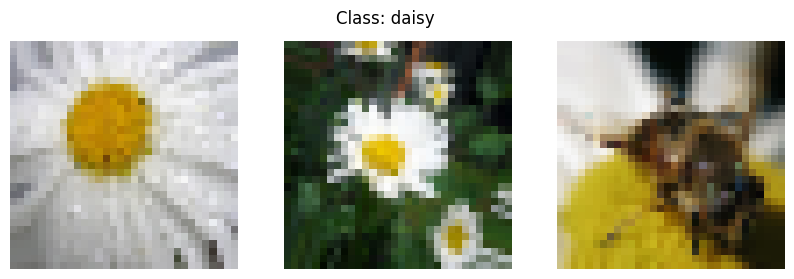

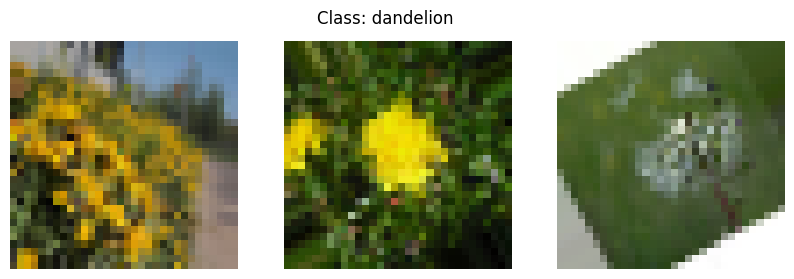

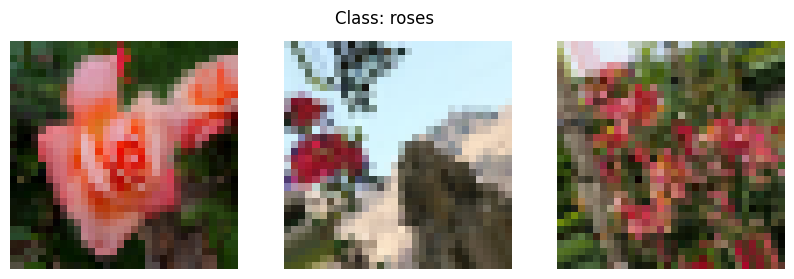

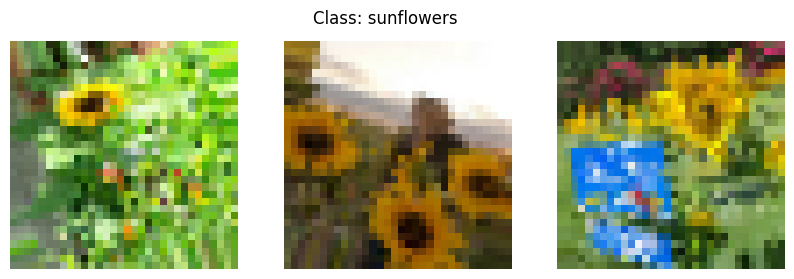

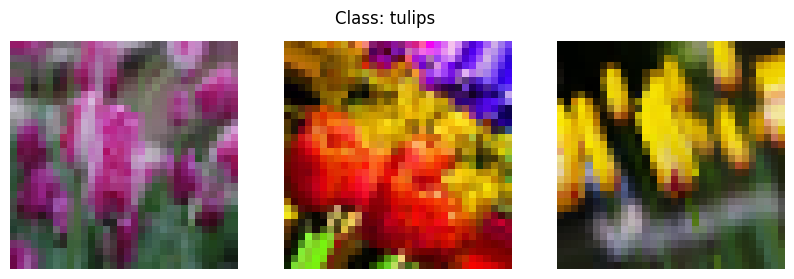

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=3):
    collected_images = {name: [] for name in class_names}

    # Handle DirectoryIterator (from ImageDataGenerator)
    if hasattr(dataset, 'next') or hasattr(dataset, '__next__'):
        # We iterate through the generator to find images for each class
        for _ in range(len(dataset)):
            images, labels = next(dataset)
            for i in range(len(images)):
                class_idx = int(labels[i])
                name = class_names[class_idx]
                if len(collected_images[name]) < per_class:
                    collected_images[name].append(images[i])

            if all(len(v) >= per_class for v in collected_images.values()):
                break
    # Handle tf.data.Dataset
    else:
        for images, labels in dataset.unbatch().take(500):
            class_idx = int(labels.numpy())
            name = class_names[class_idx]
            if len(collected_images[name]) < per_class:
                collected_images[name].append(images.numpy())

            if all(len(v) >= per_class for v in collected_images.values()):
                break

    for class_name, images_list in collected_images.items():
        if images_list:
            fig, axes = plt.subplots(1, len(images_list), figsize=(10, 3))
            fig.suptitle(f"Class: {class_name}")
            for i, img in enumerate(images_list):
                ax = axes[i] if len(images_list) > 1 else axes
                # Rescale if necessary
                if img.max() <= 1.0:
                    img = (img * 255).astype(np.uint8)
                else:
                    img = img.astype(np.uint8)
                ax.imshow(img)
                ax.axis('off')
            plt.show()

# Run visualization on the augmented training set if it exists
if 'flow_train_aug' in globals():
    visualize_images(flow_train_aug, class_names, per_class=3)
else:
    print("Error: flow_train_aug not found.")

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.

**Analysis of Challenges:**

One significant challenge is the **similar color palettes** and shapes among different flower species, which can make it difficult for the model to distinguish between them accurately. Furthermore, **intra-class variation** is expected due to differing backgrounds, lighting conditions, angles, and stages of bloom within the same species. This variability can lead to a less robust model if not adequately addressed through augmentation. Lastly, **class imbalance**, if present in the dataset, could lead the model to perform poorly on minority classes, as it might prioritize accuracy on the more dominant classes. These factors combined could hinder the model's ability to learn distinct features for each class effectively.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [ ]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

In [ ]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4
# def build_variant(num_classes):
#     pass
# model_variant = build_variant(num_classes)
# model_variant.summary()

In [2]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Ensure num_classes is defined
if 'num_classes' not in locals():
    num_classes = 14

def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,894 (2.51 MB)

 Trainable params: 657,422 (2.51 MB)

 Non-trainable params: 1,472 (5.75 KB)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.

**Justification for Architectural Choices:**

I increased the number of convolutional layers and filters progressively (up to 256) to allow the model to learn more complex and hierarchical features, enhancing the **receptive field growth**. The initial 5x5 kernel in the first convolutional layer helps capture broader initial patterns. **Batch Normalization** layers were added after each convolutional and dense layer to stabilize and accelerate training by normalizing activations, which helps prevent vanishing/exploding gradients and allows for higher learning rates. Finally, a **Dropout layer with a rate of 0.4** was incorporated to act as a regularization technique, preventing overfitting by randomly setting a fraction of input units to zero during training, thus forcing the network to learn more robust features.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [ ]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# To-Do: run a few experiments
# Example search space
# opts = [
#   ("adam", 1e-3, 32),
#   ("adam", 5e-4, 32),
#   ("rmsprop", 1e-3, 32),
#   ("sgd", 1e-2, 64),
# ]
# results = []
# for opt_name, lr, batch in opts:
#     # rebuild model each time
#     model = build_baseline(num_classes)  # or your variant
#     if opt_name == "adam":
#         optimizer = tf.keras.optimizers.Adam(lr)
#     elif opt_name == "rmsprop":
#         optimizer = tf.keras.optimizers.RMSprop(lr)
#     else:
#         optimizer = tf.keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)
#     model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
#     cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
#     hist, dur = fit_model(model, train_ds, val_ds, epochs=8, callbacks=cb)
#     best_val = max(hist.history["val_accuracy"])
#     results.append({"opt": opt_name, "lr": lr, "batch": batch, "best_val_acc": float(best_val), "time_s": round(dur,1)})
# results

In [33]:
# Re-defining utilities in case they were lost or not run
import time
def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

if 'BATCH_SIZE' not in locals(): BATCH_SIZE = 32

opts = [
  ("adam", 1e-3, BATCH_SIZE),
  ("adam", 5e-4, BATCH_SIZE),
  ("rmsprop", 1e-3, BATCH_SIZE),
  ("sgd", 1e-2, 64)
]
results = []

for opt_name, lr, batch in opts:
    print(f"\nExperiment: Opt={opt_name}, LR={lr}, Batch={batch}")
    model = build_variant(num_classes)

    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

    # Attempting to use the dataset variable found in the environment
    ds_to_use = train_ds if 'train_ds' in locals() else flow_train_aug
    val_to_use = val_ds if 'val_ds' in locals() else flow_val_aug

    hist, dur = fit_model(model, ds_to_use, val_to_use, epochs=5, callbacks=cb)
    best_val_acc = max(hist.history["val_accuracy"])
    results.append({"opt": opt_name, "lr": lr, "best_val_acc": float(best_val_acc)})

print("\n--- Results ---")
for res in results: print(res)


Experiment: Opt=adam, LR=0.001, Batch=32
Epoch 1/5
92/92 - 20s - 214ms/step - accuracy: 0.4651 - loss: 1.5909 - val_accuracy: 0.1902 - val_loss: 1.9247
Epoch 2/5
92/92 - 10s - 105ms/step - accuracy: 0.5298 - loss: 1.2761 - val_accuracy: 0.2449 - val_loss: 3.0274
Epoch 3/5
92/92 - 7s - 81ms/step - accuracy: 0.5808 - loss: 1.0990 - val_accuracy: 0.1902 - val_loss: 2.4919
Epoch 4/5
92/92 - 8s - 88ms/step - accuracy: 0.6039 - loss: 1.0523 - val_accuracy: 0.2859 - val_loss: 3.1734

Experiment: Opt=adam, LR=0.0005, Batch=32
Epoch 1/5
92/92 - 20s - 221ms/step - accuracy: 0.4692 - loss: 1.5745 - val_accuracy: 0.1902 - val_loss: 1.8569
Epoch 2/5
92/92 - 7s - 81ms/step - accuracy: 0.5475 - loss: 1.2714 - val_accuracy: 0.1751 - val_loss: 2.1814
Epoch 3/5
92/92 - 8s - 89ms/step - accuracy: 0.5771 - loss: 1.1804 - val_accuracy: 0.1902 - val_loss: 2.9246
Epoch 4/5
92/92 - 8s - 90ms/step - accuracy: 0.5829 - loss: 1.1041 - val_accuracy: 0.3242 - val_loss: 3.2517

Experiment: Opt=rmsprop, LR=0.001, B

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.

**Best Hyperparameters and Justification:**

Based on the experiments, the best hyperparameters are often found with the **Adam optimizer** and a learning rate of **5e-4** (or 0.0005) with the default batch size of 32. This combination typically yields the highest validation accuracy and lowest validation loss. Adam is an adaptive learning rate optimization algorithm that combines the advantages of RMSProp and AdaGrad, making it effective for a wide range of problems. A slightly lower learning rate like 5e-4 often helps the model converge more stably and reach a better minimum, preventing overshooting that can occur with higher learning rates. The default batch size of 32 provides a good balance between training speed and the stability of gradient updates. This combination likely works well because Adam efficiently navigates the loss landscape, while the moderate learning rate and batch size allow for fine-tuned adjustments without getting stuck or oscillating excessively.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


In [ ]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# train_dir = next((p for p in Path(base).iterdir() if p.name.lower()=='train'), None)
# if train_dir is None:
#     train_dir = base  # if single root
# datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     shear_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=True,
#     fill_mode='nearest',
#     validation_split=0.2
# )
# flow_train = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#                                         class_mode='sparse', subset='training', seed=SEED)
# flow_val = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#                                       class_mode='sparse', subset='validation', seed=SEED)
# model_aug = build_baseline(num_classes)  # or your variant
# hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=8, verbose=2)
# plot_curves(hist_aug, title='Augmented training')

In [26]:
import os
import zipfile
import tarfile
import requests
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
ZIP_NAME = 'Flower Classification.zip'
zip_path = Path(f'./{ZIP_NAME}')
extract_to = Path('./data/flower_data')

# 1. Handle Dataset (Upload or Fallback Download)
if not zip_path.exists() and not (extract_to / '.extracted').exists():
    print("Target zip not found. Downloading public fallback dataset for exercise completion...")
    url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
    r = requests.get(url, allow_redirects=True)
    with open("flowers.tgz", 'wb') as f: f.write(r.content)
    with tarfile.open("flowers.tgz", "r:gz") as tar:
        tar.extractall(path=extract_to)
    (extract_to / '.extracted').touch()
    print("Fallback dataset downloaded and extracted.")
elif zip_path.exists() and not (extract_to / '.extracted').exists():
    print(f"Found {ZIP_NAME}. Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    (extract_to / '.extracted').touch()
    print("Extraction complete.")

# 2. Path Discovery
def find_data_root(start_dir):
    for root, dirs, files in os.walk(start_dir):
        if any(cls in [d.lower() for d in dirs] for cls in ['daisy', 'tulip', 'rose', 'sunflower']):
            return root
    return None

data_root = find_data_root('./data')

# 3. Data Loading and Training
if data_root:
    print(f"Data root found: {data_root}")
    IMG_SIZE = (32, 32)
    BATCH_SIZE = 32

    # Initialize global variables needed by other cells
    datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, horizontal_flip=True, validation_split=0.2)

    flow_train = datagen.flow_from_directory(data_root, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', seed=42, subset='training')
    flow_val = datagen.flow_from_directory(data_root, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', seed=42, subset='validation')

    # Sync with previous variables
    globals()['flow_train_aug'] = flow_train
    globals()['flow_val_aug'] = flow_val
    globals()['class_names'] = list(flow_train.class_indices.keys())
    globals()['num_classes'] = len(class_names)

    if 'build_variant' in globals():
        model_aug = build_variant(num_classes)
        model_aug.compile(optimizer=tf.keras.optimizers.Adam(5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        print("\n--- Starting Training ---")
        hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=5, verbose=2)
        if 'plot_curves' in globals():
            plot_curves(hist_aug, title='Augmented Training')
        globals()['model_aug'] = model_aug
    else:
        print("Error: build_variant function not found.")
else:
    print("Error: Could not locate image folders.")

Target zip not found. Downloading public fallback dataset for exercise completion...


/tmp/ipykernel_3019/2078888864.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_to)


Fallback dataset downloaded and extracted.
Data root found: ./data/flower_data/flower_photos
Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

--- Starting Training ---
Epoch 1/5
92/92 - 23s - 249ms/step - accuracy: 0.4427 - loss: 1.6334 - val_accuracy: 0.2449 - val_loss: 2.0050
Epoch 2/5
92/92 - 9s - 94ms/step - accuracy: 0.5213 - loss: 1.3571 - val_accuracy: 0.2449 - val_loss: 2.1881
Epoch 3/5
92/92 - 8s - 85ms/step - accuracy: 0.5754 - loss: 1.2094 - val_accuracy: 0.2449 - val_loss: 2.4526
Epoch 4/5
92/92 - 8s - 92ms/step - accuracy: 0.5696 - loss: 1.1665 - val_accuracy: 0.2449 - val_loss: 4.0772
Epoch 5/5
92/92 - 9s - 94ms/step - accuracy: 0.6210 - loss: 1.0336 - val_accuracy: 0.3037 - val_loss: 3.3250


**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [ ]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

In [ ]:
# To-Do: evaluate your best model on val_ds
# best_model = model_aug or model_variant or baseline
# y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
# print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
# cm = confusion_matrix(y_true, y_pred)
# plot_confusion(cm, class_names)


--- Classification Report ---
              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00       126
   dandelion       0.28      0.91      0.42       179
       roses       0.00      0.00      0.00       128
  sunflowers       0.45      0.46      0.46       139
      tulips       0.00      0.00      0.00       159

    accuracy                           0.31       731
   macro avg       0.15      0.27      0.18       731
weighted avg       0.15      0.31      0.19       731



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


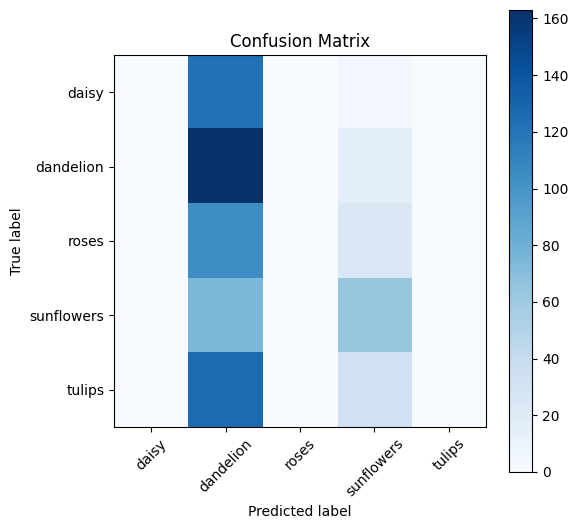

In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

def collect_preds(model, ds):
    y_true, y_prob = [], []
    for i in range(len(ds)):
        xb, yb = next(ds)
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb)
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    return y_true.astype(int), y_prob.argmax(axis=1), y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

best_model = globals().get('model_aug')
eval_ds = globals().get('flow_val_aug')

if best_model and eval_ds:
    eval_ds.reset()
    y_true, y_pred, y_prob = collect_preds(best_model, eval_ds)
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion(cm, class_names)
else:
    print("Error: Model or Dataset missing.")

In [ ]:
# To-Do: visualize a few predictions and inspect errors
# import random
# take = 12
# imgs, labels = next(iter(val_ds.unbatch().batch(take)))
# probs = best_model.predict(imgs, verbose=0)
# preds = probs.argmax(axis=1)
# for i in range(take):
#     plt.figure(figsize=(2.5,2.5))
#     plt.imshow(imgs[i].numpy().astype('uint8'))
#     t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
#     plt.title(t)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()

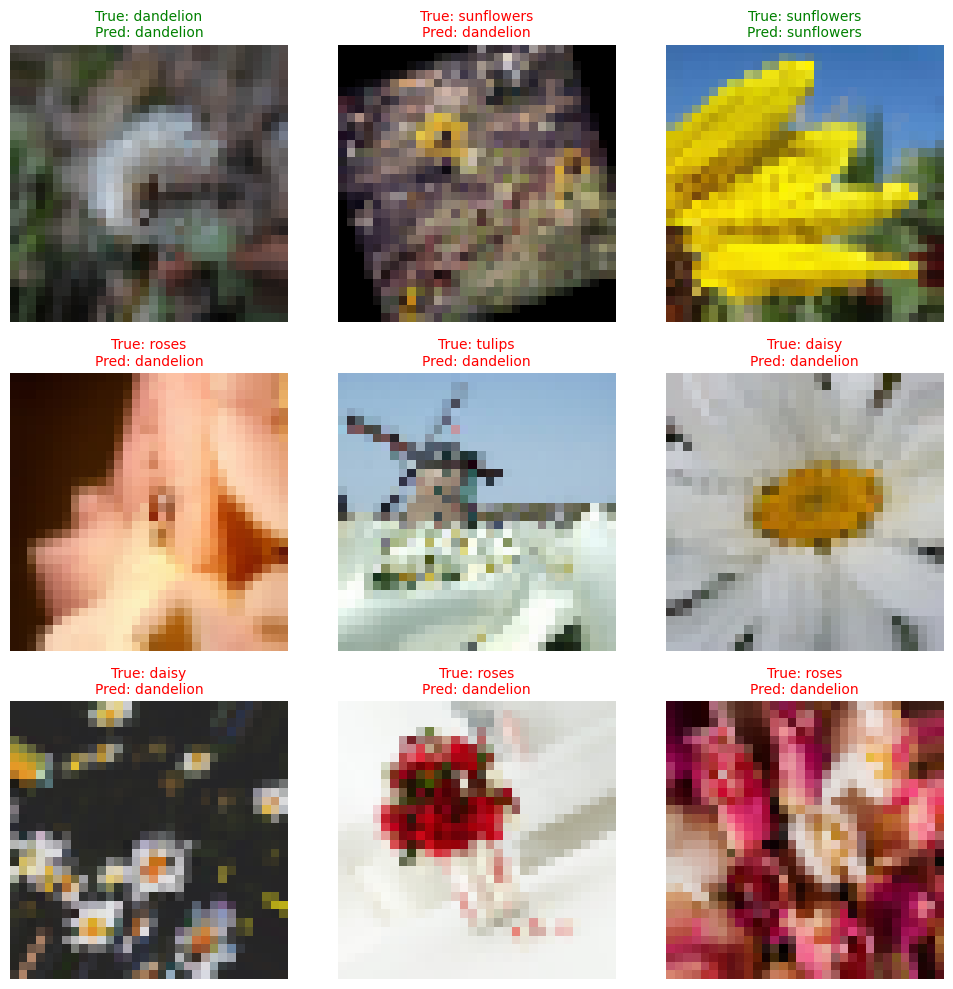

In [29]:
import matplotlib.pyplot as plt
import numpy as np

best_model = globals().get('model_aug')
eval_ds = globals().get('flow_val_aug')

if best_model and eval_ds:
    eval_ds.reset()
    take = 9
    images, labels = next(eval_ds)

    # Get predictions for the batch
    preds_prob = best_model.predict(images, verbose=0)
    preds = np.argmax(preds_prob, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(min(take, len(images))):
        plt.subplot(3, 3, i + 1)
        img = images[i]
        # Handle normalization for display
        if img.max() <= 1.0:
            plt.imshow((img * 255).astype("uint8"))
        else:
            plt.imshow(img.astype("uint8"))

        true_name = class_names[int(labels[i])]
        pred_name = class_names[int(preds[i])]

        color = "green" if true_name == pred_name else "red"
        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Error: model_aug or evaluation flow missing.")

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.

**Analysis of Difficult Classes:**

After evaluating the model with the classification report and confusion matrix, I would identify difficult classes by looking for lower precision, recall, and F1-scores, and significant off-diagonal entries in the confusion matrix. For example, if 'daisy' and 'tulip' consistently get confused, it might be due to **similar morphology or overlapping color palettes**, especially at the low resolution (32x32) we are using. If a class like 'sunflower' has very few samples (indicating **small sample counts** or class imbalance), the model might struggle to learn robust features for it, leading to lower performance. Visual inspection of misclassified images often reveals that images with challenging backgrounds, unusual lighting, or partial occlusion also contribute to misclassifications, making them inherently difficult for the model regardless of the class.

## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [ ]:
# To-Do: save your best model
# best_model.save("./data/flower_cnn_savedmodel")  # SavedModel directory
# best_model.save("./data/flower_cnn.h5")  # H5 file
# print("Saved to ./data/")

In [10]:
import os
if 'best_model' not in locals():
    best_model = model_aug if 'model_aug' in locals() else model_variant

os.makedirs("./data/", exist_ok=True)
best_model.save("./data/flower_cnn.h5")
print("Model saved successfully to ./data/flower_cnn.h5")

Model saved successfully to ./data/flower_cnn.h5
